# Functions of Two Variables

**This notebook teaches multivariable functions from scratch, it assumes only that you can read a graph.**

Every function so far took one number and returned one number, and its graph was a curve. But almost
nothing real depends on a single variable. A house price depends on size *and* location *and* age; a
model's error depends on every one of its parameters. A function of two inputs, $f(x, y)$, graphs as a
**surface** instead of a curve, and once you can read a surface, the calculus that follows is mostly
the one-variable calculus you already know, applied one direction at a time.

## Learning objectives

- Read a **surface** $z = f(x,y)$ as the graph of a two-input function.
- Recognize a **bowl** and a **saddle**, and say where each is high or low.
- Take a **slice** through a surface and recover an ordinary one-variable curve.

## Background

A function of two variables assigns a height to every point of the plane:

$$z = f(x, y)$$

Plotting the height above each $(x, y)$ traces out a **surface**. Two shapes are worth knowing by name:

- $f(x,y) = x^2 + y^2$, a **bowl** (a paraboloid). Lowest at the origin, rising in every direction.
- $f(x,y) = x^2 - y^2$, a **saddle**. At the origin it curves *up* along $x$ and *down* along $y$,
  so it is neither a peak nor a valley.

The saddle is the important one. It is why the single-variable optimization test of §3.5 does not
transfer directly: a point can be flat in every direction and still be neither a maximum nor a minimum.

The key technique is **slicing**. Hold $y$ fixed at some value and $f(x, y)$ becomes a function of $x$
alone, an ordinary curve you already know how to differentiate. That idea *is* the partial derivative,
which is the next notebook.

## This notebook covers

1. The bowl.
2. The saddle, from several angles.
3. Contour maps: a surface seen from above.
4. Slices: cutting a surface back down to a curve.

**Prerequisites:** `U3-5_Optimize-1_DerivativeTest`

**Dataset:** none, functions are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from mpl_toolkits.mplot3d import Axes3D     # noqa: F401  (registers the 3d projection)

## 1. The bowl

Start with $f(x, y) = x^2 + y^2$. At the origin it is zero, and moving away in *any* direction makes it
larger, so the surface is a bowl with its lowest point at the centre.

3-D plots in a notebook are static images, so we show the same surface from a few viewing angles
rather than relying on rotation. Reading a 3-D plot takes practice; the contour map in section 3 is
often easier.

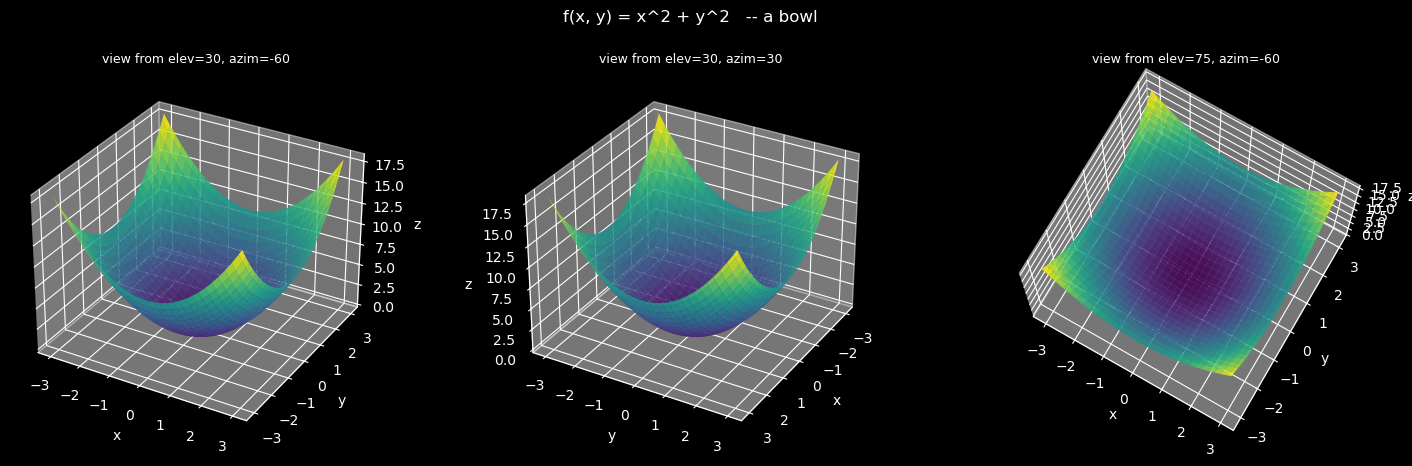

In [2]:
def bowl(x, y):
    return x**2 + y**2

n = 60
xs = np.linspace(-3, 3, n)
ys = np.linspace(-3, 3, n)
X, Y = np.meshgrid(xs, ys)
Z = bowl(X, Y)

fig = plt.figure(figsize=(15, 4.5))
for k, (elev, azim) in enumerate([(30, -60), (30, 30), (75, -60)]):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", alpha=0.9)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(f"view from elev={elev}, azim={azim}", pad=8, fontsize=9)
plt.suptitle("f(x, y) = x^2 + y^2   -- a bowl", y=1.0)
plt.tight_layout()
plt.show()

## 2. The saddle

Now $f(x, y) = x^2 - y^2$. The sign flip on the second term changes everything: moving along the $x$
axis the surface goes **up**, and moving along the $y$ axis it goes **down**.

At the origin the surface is perfectly flat, and it is neither a peak nor a valley. That configuration
is called a **saddle point** (it is the shape of a horse's saddle, or a mountain pass). Watch for it
below: along one axis the origin looks like a minimum, along the other it looks like a maximum.

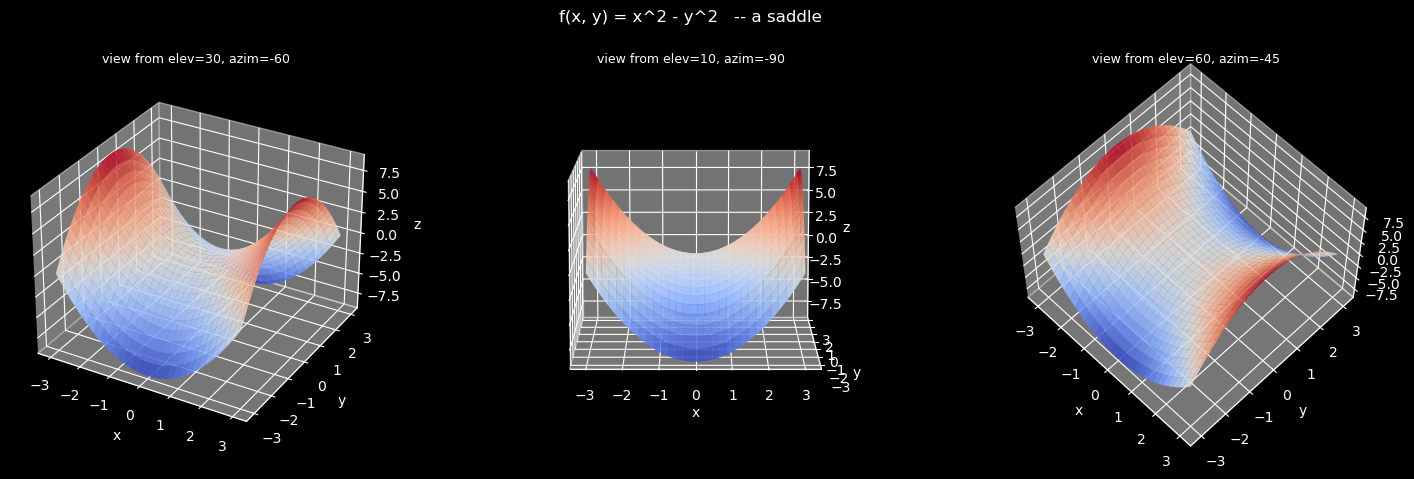

at the origin:      f(0, 0) = 0.0
moving along x:     f(1, 0) = +1.0   -> higher
moving along y:     f(0, 1) = -1.0   -> lower

flat at the origin, but neither a maximum nor a minimum -- a SADDLE POINT.


In [3]:
def saddle(x, y):
    return x**2 - y**2

Zs = saddle(X, Y)

fig = plt.figure(figsize=(15, 4.5))
for k, (elev, azim) in enumerate([(30, -60), (10, -90), (60, -45)]):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    ax.plot_surface(X, Y, Zs, cmap="coolwarm", edgecolor="none", alpha=0.9)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(f"view from elev={elev}, azim={azim}", pad=8, fontsize=9)
plt.suptitle("f(x, y) = x^2 - y^2   -- a saddle", y=1.0)
plt.tight_layout()
plt.show()

print(f"at the origin:      f(0, 0) = {saddle(0, 0):.1f}")
print(f"moving along x:     f(1, 0) = {saddle(1, 0):+.1f}   -> higher")
print(f"moving along y:     f(0, 1) = {saddle(0, 1):+.1f}   -> lower")
print("\nflat at the origin, but neither a maximum nor a minimum -- a SADDLE POINT.")

## 3. Contour maps

A **contour map** is the surface seen from directly above, with lines joining points of equal height, exactly how a topographic map shows terrain. It is often far easier to read than the 3-D view, and
this is the picture the rest of the section uses.

Two things to read off a contour map:

- **closely spaced** lines mean the surface is steep there; widely spaced lines mean it is nearly flat;
- the **shape** of the contours tells you the shape of the surface, concentric rings for a bowl,
  hyperbolas for a saddle.

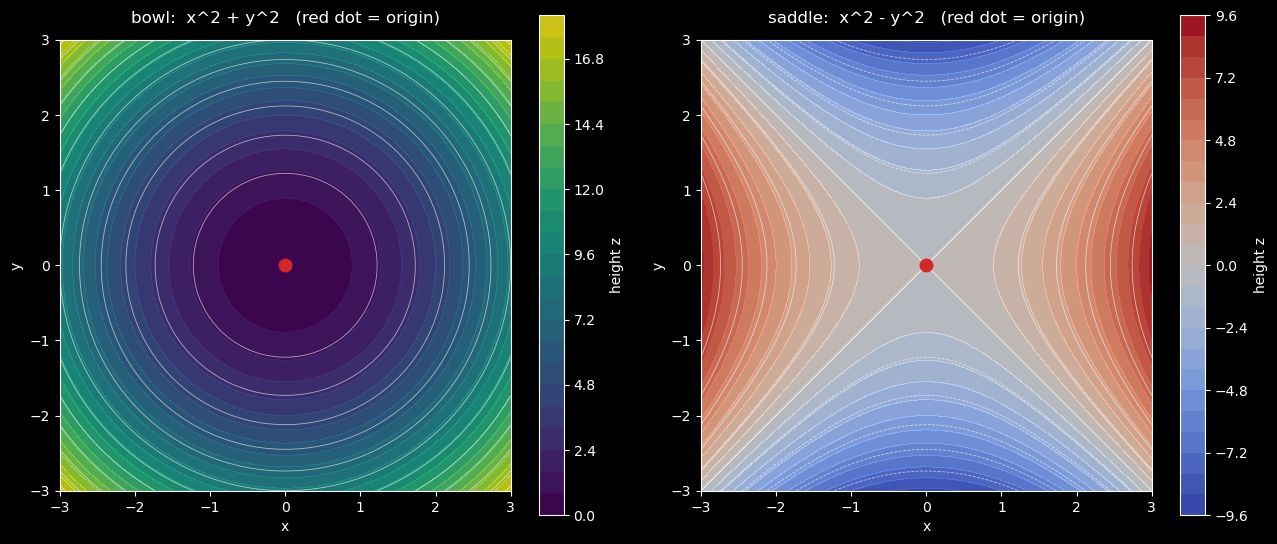

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, Zc, name, cmap in [(axes[0], Z, "bowl:  x^2 + y^2", "viridis"),
                           (axes[1], Zs, "saddle:  x^2 - y^2", "coolwarm")]:
    cs = ax.contourf(X, Y, Zc, levels=25, cmap=cmap, alpha=0.85)
    ax.contour(X, Y, Zc, levels=12, colors="white", linewidths=0.6, alpha=0.6)
    fig.colorbar(cs, ax=ax, label="height z")
    ax.plot(0, 0, "o", color="tab:red", markersize=9)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_title(name + "   (red dot = origin)", pad=12)
plt.tight_layout()
plt.show()

The bowl's contours are **circles** closing in on the minimum. The saddle's are **hyperbolas** that
open out in two opposite directions, the visual signature of a saddle point.

## 4. Slicing back down to one variable

Here is the move that makes the rest of multivariable calculus manageable. Hold one variable **fixed**
and the surface becomes an ordinary curve.

Fix $y = 0$ in the saddle: $f(x, 0) = x^2 - 0 = x^2$, an upward parabola. Fix $x = 0$ instead:
$f(0, y) = -y^2$, a downward parabola. Same surface, two slices, opposite shapes, which is precisely
the saddle's defining property, now expressed as two familiar one-variable curves.

Every slice is a curve you already know how to differentiate. The slope of a slice is what the next
notebook calls a **partial derivative**.

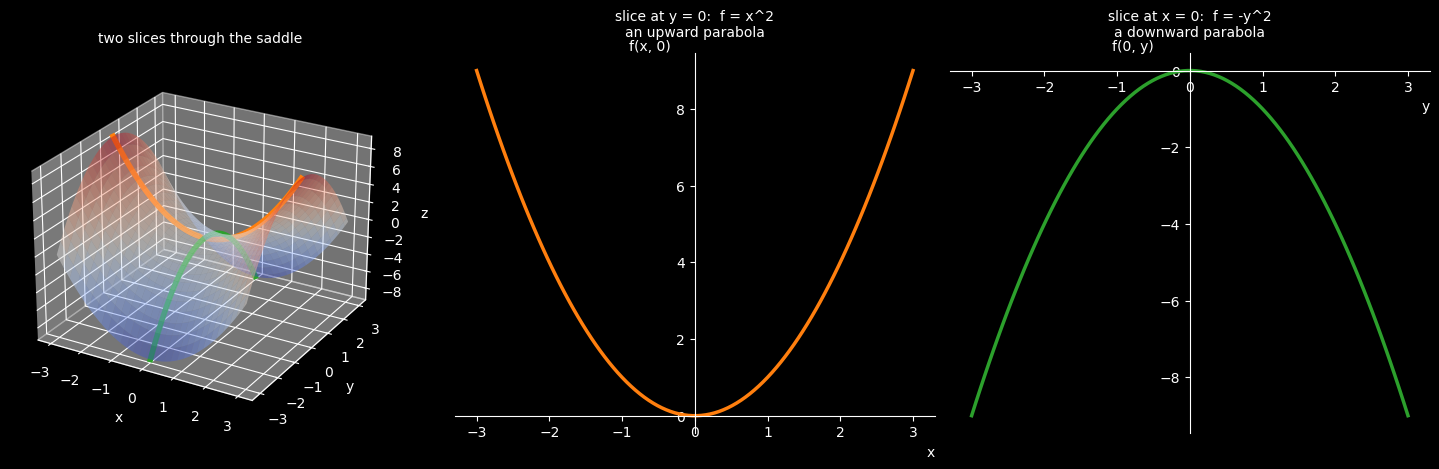

In [5]:
fig = plt.figure(figsize=(15, 4.8))

# the surface, with the two slice curves drawn on it
ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.plot_surface(X, Y, Zs, cmap="coolwarm", edgecolor="none", alpha=0.45)
line = np.linspace(-3, 3, 100)
ax.plot(line, np.zeros_like(line), saddle(line, 0), color="tab:orange", lw=4)   # y = 0
ax.plot(np.zeros_like(line), line, saddle(0, line), color="tab:green", lw=4)    # x = 0
ax.view_init(elev=25, azim=-60)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("two slices through the saddle", pad=8, fontsize=10)

ax = fig.add_subplot(1, 3, 2)
ax.plot(line, saddle(line, 0), color="tab:orange", lw=2.5)
center_axes(ax)
ax.set_xlabel("x", loc="right"); ax.set_ylabel("f(x, 0)", loc="top", rotation=0)
ax.set_title("slice at y = 0:  f = x^2\nan upward parabola", pad=12, fontsize=10)

ax = fig.add_subplot(1, 3, 3)
ax.plot(line, saddle(0, line), color="tab:green", lw=2.5)
center_axes(ax)
ax.set_xlabel("y", loc="right"); ax.set_ylabel("f(0, y)", loc="top", rotation=0)
ax.set_title("slice at x = 0:  f = -y^2\na downward parabola", pad=12, fontsize=10)

plt.tight_layout()
plt.show()

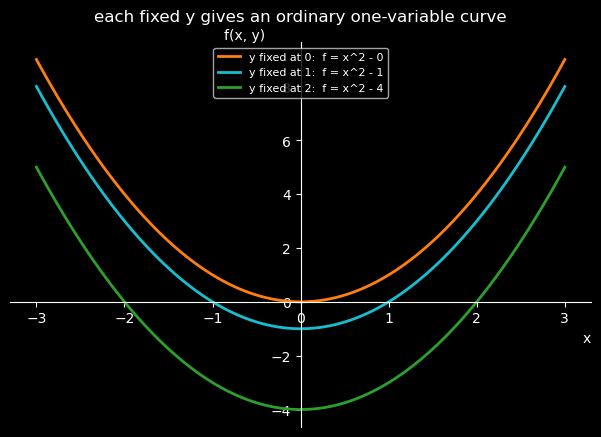

In [6]:
# slices don't have to pass through the origin -- any fixed y gives a curve
fig, ax = plt.subplots(figsize=(7.5, 5))
for y_fixed, color in zip([0, 1, 2], ["tab:orange", "tab:cyan", "tab:green"]):
    ax.plot(line, saddle(line, y_fixed), color=color, lw=2,
            label=f"y fixed at {y_fixed}:  f = x^2 - {y_fixed**2}")
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f(x, y)", loc="top", rotation=0)
ax.legend(loc="upper center", fontsize=8)
ax.set_title("each fixed y gives an ordinary one-variable curve", pad=15)
plt.show()

## 5. Summary

- A function of two variables $z = f(x,y)$ graphs as a **surface**: a height above every point of the plane.
- A **bowl** ($x^2+y^2$) has a genuine minimum; a **saddle** ($x^2-y^2$) is flat at the origin but is
  neither a maximum nor a minimum, it rises one way and falls the other.
- A **contour map** shows the surface from above; tightly packed lines mean steep. Circles indicate a
  bowl, hyperbolas a saddle.
- **Slicing**: fixing one variable: turns a surface back into an ordinary curve, which you already
  know how to handle.

Next: the slope of a slice, which is the **partial derivative**
(`U3-6_Multivariable-2_PartialDerivatives`).